*Usage estimate of QPU time for the notebook excluding the bonus part: 5 min 30 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The QPU usage estimate reflects only backend execution time. Queueing, calibration, and runtime session delays can extend total execution to several minutes, even for workloads using only seconds of QPU time.*

In Lab 4a, we explored what quantum advantage means and how the [Quantum Advantage Tracker](https://quantum-advantage-tracker.github.io/) classifies demonstrations into three categories: classically verifiable problems, variational problems, and observable estimation. We saw examples like the $ \mathrm{Fe}_4\mathrm{S}_4$ molecule computation (variational) and the Loschmidt Echo calculation (observable estimation).

Now we turn to the first category: **classically verifiable problems**. These are optimization problems where we can efficiently verify if a quantum solution is correct, even if finding that solution classically is exponentially hard. This makes them ideal candidates for demonstrating quantum advantage, since we can prove the quantum computer found a good answer without needing an equally powerful classical computer to check it.

In this lab, we will explore the [Quantum Approximate Optimization Algorithm (QAOA)](https://quantum.cloud.ibm.com/learning/courses/quantum-computing-in-practice/utility-scale-qaoa) applied to the Partition Problem. QAOA is particularly promising because:
- It is designed for near-term quantum hardware (no error correction needed)
- Solutions are easy to verify classically
- It has the potential to demonstrate quantum advantage as we scale to larger problem sizes

The partition problem asks: given a set of numbers, can we split them into two groups with equal sums? While this sounds simple, it becomes exponentially harder as the problem size grows, making it a perfect testbed for quantum advantage. Let's see how QAOA tackles it!

### Install the necessary libraries

In [1]:
# %pip install qc-grader
# %pip install mthree
# %pip install qiskit-addon-opt-mapper
# %pip install git+https://github.com/qiskit-community/qopt-best-practices.git
# %pip install qiskit-aer
# %pip install matplotlib
# %pip install pandas
# %pip install pylatexenc

### Setting up the `utils` folder

Wether you use a local environment (such as [VSCode](https://code.visualstudio.com/)) or an online enviornment (such as [qBraid](https://www.qbraid.com/)), make sure that you place the `utils` folder in the same directory as the notebook. Otherwise you will receive a ModuleNotFoundError when you execute the Imports cell.

### Imports

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp

from scipy.optimize import minimize
import networkx as nx
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    EstimatorV2 as Estimator,
    SamplerV2 as Sampler,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.options import SamplerOptions, EstimatorOptions
import mthree

from qiskit_addon_opt_mapper.applications import Maxcut
from qiskit_addon_opt_mapper.translators import to_ising
from qopt_best_practices.circuit_library import annotated_qaoa_ansatz
from qopt_best_practices.transpilation import UnrollBoxes

from qiskit.transpiler import CouplingMap
from qopt_best_practices.transpilation.generate_preset_qaoa_pass_manager import (
    generate_preset_qaoa_pass_manager,
)
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy
from itertools import combinations

# Import utils
from utils.functions import plot_partition_graph, analyze_partition_result
from utils.functions import (
    analyze_error_mitigation_result,
    compare_error_mitigation_methods,
    plot_error_mitigation_comparison,
    print_comparison_summary,
)
from utils.functions import get_partitions, calc_cut_size

from random import sample

# Set seed for reproducibility
seed = 42

ModuleNotFoundError: No module named 'qiskit'

Throughout the Lab you can use the `check_progress` function to see how many exercises you have completed:

In [ ]:
check_progress()

We choose the backend

In [ ]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=156)
print(f"We are using {backend.name}")

Note that this lab is intended to be run on a QPU. However, if you run out of QPU time, you can still complete most of it (everything except part (b) of the Bonus exercise) using a simulator. To do so, uncomment the following cell

In [ ]:
# from qiskit_aer import AerSimulator
# backend = AerSimulator.from_backend(backend)

# 2. Applying different Error Mitigation and Suppression techniques to the Sampler

Now we are going to apply different [error mitigation and suppression techniques](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques) to try to get the best results for the partition problem. This will complement the techniques you learned in Lab 3 from a more practical perspective - in particular, in a quantum optimization setting. 

<a id="exercise_2"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 2: Use the Sampler with different levels of Error Mitigation techniques</b>

**Your Goal:** Apply different error mitigation techniques to the quantum circuit execution and compare the results.

Test the following four configurations using 1000 shots:

- **2a: No Error Mitigation or Suppression** (baseline)  
  Raw hardware results without any error mitigation or suppression techniques

- **2b: Error Suppression + Twirling**  
  Dynamical Decoupling + Pauli Twirling (gates and measure) to suppress coherent errors during circuit execution

- **2c: M3 Error Mitigation Only**  
  Matrix-free Measurement Mitigation to correct readout errors in post-processing

- **2d: M3 Error Mitigation + Error Suppression + Twirling** (full stack)  
  Combined approach using both suppression during execution and mitigation in post-processing

Compare the accuracy and performance of each approach to understand the impact of different error mitigation strategies.

</div>

First we will define the [`SamplerOptions`](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-sampler-options) object for each case and then we will run the workflows.

In [ ]:
# =============================================================================
# VERSION 1: No Error Mitigation or Suppression
# =============================================================================
print("=" * 80)
print("VERSION 1: No Error Mitigation or Suppression")
print("=" * 80)

options_v1 = SamplerOptions()
# ---- TODO : Task 2a ---
# Set the number of shots to 1000 and define the SamplerOptions for the quantum circuit execution
shots = 
options_v1.default_shots = 
# ---- end of TODO : Task 2a ---

In [ ]:
## Verify your answer ##
grade_lab4b_ex2a(options_v1)

Now apply [Dynamical Decoupling](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-dynamical-decoupling-options) and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-twirling-options) (gates and measure twirling). 

In [ ]:
# =============================================================================
# VERSION 2: Error Suppression Only (Dynamical Decoupling + Twirling)
# =============================================================================
print("=" * 80)
print("VERSION 2: Error Suppression Only")
print("=" * 80)


options_v2 = SamplerOptions()
# ---- TODO : Task 2b ---
# Configure error suppression options
options_v2.default_shots = 
# Set dynamical decoupling to reduce decoherence errors
options_v2.dynamical_decoupling.enable = 
options_v2.dynamical_decoupling.sequence_type = 
# Enable gate twirling to randomize coherent errors
options_v2.twirling.enable_gates = 
# Enable measurement twirling to randomize readout errors
options_v2.twirling.enable_measure = 
options_v2.twirling.num_randomizations = 

# ---- end of TODO : Task 2b ---

In [ ]:
## Verify your answer ##
grade_lab4b_ex2b(options_v2)

Now that you have succesfully completed Ex2a and Ex2b, we will run those workflows to use the results to be further post-processed by the M3 technique.

*Usage estimate: 5 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# =============================================================================
# VERSION 1: No Error Mitigation or Suppression
# =============================================================================
# No error mitigation or suppression options set
sampler_v1 = Sampler(mode=backend, options=options_v1)
sampler_v1.options.environment.job_tags = ["qgss26"]

pub_v1 = (optimized_circuit,)
job_v1 = sampler_v1.run([pub_v1], shots=shots)
print ("Job ID of job_v1:", job_v1.job_id())
counts_bin_v1 = job_v1.result()[0].data.meas.get_counts()

final_distribution_bin_v1 = {key: val / shots for key, val in counts_bin_v1.items()}

final_distribution_bin_v1 = dict(
    sorted(final_distribution_bin_v1.items(), key=lambda item: item[1], reverse=True)
)
print("Results (no mitigation):")
print(final_distribution_bin_v1)

**Troubleshooting: Retrieving Lost Jobs**

If you lose access to your job variables due to a kernel restart or session interruption, you can still retrieve your results without rerunning the job on hardware. This saves valuable QPU time. Execute the cell below to retrieve a job using its job ID.

If you do not have the job ID readily available, you can find it in [IBM Quantum Platform](https://quantum.cloud.ibm.com/) by checking your job history under the Jobs tab.

In [ ]:
job_id_v1= job_v1.job_id()
# Alternatively, you can also subsittute the job_id_v1 by the actual string of the job ID, e.g. "d8slqn5bh0os73eoe0lk"
job_v1_retrieved = service.job(job_id_v1)

*Usage estimate: 5 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# =============================================================================
# VERSION 2: Error Suppression Only (Dynamical Decoupling + Twirling)
# =============================================================================
sampler_v2 = Sampler(mode=backend, options=options_v2)
sampler_v2.options.environment.job_tags = ["qgss26"]

pub_v2 = (optimized_circuit,)
job_v2 = sampler_v2.run([pub_v2], shots=shots)
print ("Job ID of job_v2:", job_v2.job_id())
counts_bin_v2 = job_v2.result()[0].data.meas.get_counts()
final_distribution_bin_v2 = {key: val / shots for key, val in counts_bin_v2.items()}
final_distribution_bin_v2 = dict(
    sorted(final_distribution_bin_v2.items(), key=lambda item: item[1], reverse=True)
)
print("Results (error suppression only):")
print(final_distribution_bin_v2)
print()

After running these two workflows, we can use the obtained counts to be analyzed by M3.

The M3 ([Matrix‑free Measurement Mitigation](https://qiskit.github.io/qiskit-addon-mthree/)) method is a scalable approach to readout error mitigation that avoids constructing the full $2^n \times 2^n$ assignment matrix by using simplified models of readout errors. It assumes that correlations of order three and higher are negligible, which allows it to rely only on single-qubit and two-qubit assignment matrices obtained by preparing all qubits in the $\lvert 0\ldots0\rangle$ and $\lvert 1\ldots1\rangle$ states and measuring their error rates. These small $2\times2$ and $4\times4$ matrices are stored and later combined to form an effective mitigation matrix that is built only from the bitstrings observed during sampling. Because the size of this effective matrix grows with the number of sampled outcomes rather than $2^n$, M3 can be applied to circuits with much longer bitstrings than traditional linear algebra methods.

Now you are asked to use it to reduce the error in the sampling of the quantum circuit. See this [tutorial](https://quantum.cloud.ibm.com/docs/tutorials/readout-error-mitigation-sampler) for a more in-depth analysis. Also, if you want a more hands-on approach to see which functions you need to apply, see [this tutorial](https://qiskit.github.io/qiskit-addon-mthree/tutorials/01_M3_ex1.html).

*Usage estimate: 7 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# =============================================================================
# VERSION 3: M3 Error Mitigation Only
# =============================================================================
print("=" * 80)
print("VERSION 3: M3 Error Mitigation Only")
print("=" * 80)

# We copy the setup from version 1, but focus only on M3 mitigation
options_v3 = options_v1
counts_bin_v3 = counts_bin_v1
job_v3 = job_v1
# ---- TODO : Task 2c ---
# Get the physical qubit mapping from the optimized circuit using the mthree.utils.final_measurement_mapping function

meas_map_v3 = 

# Build mitigator using mthree.M3Mitigation
mit_v3 = 

# Calibrate the mitigator using the .cals_from_system method and the meas_map_v3

# Use the .apply_correction method on counts_bin_v3 to returns quasi-probabilities
m3_quasis_v3 = 
# ---- end of TODO : Task 2c ---

def convert_bin_list(dist, shots=10000):
    # Step 1: convert to (non-negative) counts
    counts = {
        k: (int(round(float(v) * shots)) if float(v) >= 0 else 0)
        for k, v in dist.items()
    }
    # Step 2: normalize
    total_counts = sum(counts.values())
    return {k: round(v / total_counts, int(np.log10(shots))) for k, v in counts.items()}


final_distribution_bin_v3 = convert_bin_list(dict(m3_quasis_v3), shots=shots)
final_distribution_bin_v3 = dict(
    sorted(final_distribution_bin_v3.items(), key=lambda item: item[1], reverse=True)
)
print("Results (M3 mitigation only):")
print(final_distribution_bin_v3)
print()

In [ ]:
## Verify your answer ##
grade_lab4b_ex2c(options_v3, optimized_circuit, meas_map_v3, m3_quasis_v3, counts_bin_v3)

*Usage estimate: 7 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# =============================================================================
# VERSION 4: M3 Error Mitigation + Error Suppression
# =============================================================================
print("=" * 80)
print("VERSION 4: M3 Error Mitigation + Error Suppression")
print("=" * 80)

options_v4 = options_v2
counts_bin_v4 = counts_bin_v2
job_v4 = job_v2
# ---- TODO : Task 2d ---
# Apply M3 correction on top of error suppression
# Get the physical qubit mapping from the optimized circuit using the mthree.utils.final_measurement_mapping function

meas_map_v4 = 

# Build mitigator using mthree.M3Mitigation
mit_v4 = 

# Calibrate the mitigator using the .cals_from_system method and the meas_map_v4

# Use the .apply_correction method on counts_bin_v4 to returns quasi-probabilities
m3_quasis_v4 = 

# ---- End of TODO : Task 2d ---
final_distribution_bin_v4 = convert_bin_list(dict(m3_quasis_v4), shots=shots)
final_distribution_bin_v4 = dict(
    sorted(final_distribution_bin_v4.items(), key=lambda item: item[1], reverse=True)
)
print("Results (M3 mitigation + error suppression):")
print(final_distribution_bin_v4)
print()

In [ ]:
## Verify your answer ##
grade_lab4b_ex2d(options_v4, optimized_circuit, meas_map_v4, m3_quasis_v4, counts_bin_v4)

In [ ]:
# =============================================================================
# Summary Comparison
# =============================================================================
print("=" * 80)
print("SUMMARY")
print("=" * 80)
print("V1 (No mitigation):              ", list(final_distribution_bin_v1.items())[:3])
print("V2 (Suppression only):           ", list(final_distribution_bin_v2.items())[:3])
print("V3 (M3 only):                    ", list(final_distribution_bin_v3.items())[:3])
print("V4 (M3 + Suppression):           ", list(final_distribution_bin_v4.items())[:3])

In [ ]:
bitstring_v1, set1_v1, set2_v1, difference_v1, v1 = analyze_partition_result(
    final_distribution_bin_v1, numbers, partition_graph, "VERSION 1: No Mitigation"
)
bitstring_v2, set_v2, set2_v2, difference_v2, v2 = analyze_partition_result(
    final_distribution_bin_v2,
    numbers,
    partition_graph,
    "VERSION 2: Error Suppression Only",
)
bitstring_v3, set1_v3, set2_v3, difference_v3, v3 = analyze_partition_result(
    final_distribution_bin_v3, numbers, partition_graph, "VERSION 3: M3 Mitigation Only"
)
bitstring_v4, set1_v4, set2_v4, difference_v4, v4 = analyze_partition_result(
    final_distribution_bin_v4,
    numbers,
    partition_graph,
    "VERSION 4: M3 + Error Suppression",
)

In [ ]:
# Collect results in a structured way
results_sampler = {
    "v1": {
        "bitstring": bitstring_v1,
        "set1": set1_v1,
        "set2": set2_v1,
        "difference": difference_v1,
        "label": "VERSION 1: No Mitigation",
    },
    "v2": {
        "bitstring": bitstring_v2,
        "set1": set_v2,
        "set2": set2_v2,
        "difference": difference_v2,
        "label": "VERSION 2: Error Suppression Only",
    },
    "v3": {
        "bitstring": bitstring_v3,
        "set1": set1_v3,
        "set2": set2_v3,
        "difference": difference_v3,
        "label": "VERSION 3: M3 Mitigation Only",
    },
    "v4": {
        "bitstring": bitstring_v4,
        "set1": set1_v4,
        "set2": set2_v4,
        "difference": difference_v4,
        "label": "VERSION 4: M3 + Error Suppression",
    },
}

# Select the version with the smallest difference
best_key, best_result = min(
    reversed(list(results_sampler.items())), key=lambda item: item[1]["difference"]
)

# Print summary
print("\n✅ Best result:")
print(f"Method     : {best_key} ({best_result['label']})")
print(f"Bitstring  : {best_result['bitstring']}")
print(f"Set 1      : {best_result['set1']}")
print(f"Set 2      : {best_result['set2']}")
print(f"Difference : {best_result['difference']}")

Now we are going to check that you have correctly executed all the jobs using the `SamplerOptions` you defined above.

In [ ]:
options_list = [options_v1, options_v2, options_v3, options_v4]
probs_list = [
    final_distribution_bin_v1,
    final_distribution_bin_v2,
    final_distribution_bin_v3,
    final_distribution_bin_v4,
]
job_list = [job_v1, job_v2, job_v3, job_v4]


## 4. Error Mitigation Comparison for PCE-Expanded Partition Problem

Building on the PCE-scaled partition problem from Section 3, we now use the Estimator primitive to systematically compare different [error mitigation techniques](https://quantum.cloud.ibm.com/learning/courses/utility-scale-quantum-computing/error-mitigation) and identify the best possible cut, progressing from basic readout error mitigation to advanced probabilistic error cancellation and zero noise extrapolation. Check out [this tutorial](https://quantum.cloud.ibm.com/docs/tutorials/combine-error-mitigation-techniques) to see how these techniques work in practice.


<a id="exercise_4"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 4: Use the Estimator with different levels of Error Mitigation techniques</b>

**Your Goal:** Apply different error mitigation techniques to the quantum circuit execution using the Estimator primitive and compare the results.

Test the following four configurations with increasing sophistication:

- **4a: No Error Mitigation** (baseline)  
  Raw hardware results without any mitigation

- **4b: TREX (Twirled Readout Error eXtinction) + PT (Pauli Twirling on gates and measures)**  
  Mitigates measurement readout errors through randomized twirling

- **4c: ZNE (Zero Noise Extrapolation) + PT (Pauli Twirling on gates and measures)**  
  Extrapolates results to the zero-noise limit using multiple noise-scaled circuits

- **4d: PEC (Probabilistic Error Cancellation) + PT (Pauli Twirling on gates and measures)**  
  Uses quasi-probability decomposition to cancel gate errors probabilistically

Compare the accuracy, computational overhead, and performance of each approach to understand the trade-offs between different error mitigation strategies.

*Note that for each configuration, you must explicitly enable the desired techniques in `EstimatorOptions`. Just setting the resilience level will not be accepted by the grader.*
</div>

First we build the `EstimatorOptions` without any error mitigation or suppression technique, just defining the number of shots to 1000.

In [ ]:
# No Error Mitigation (Resilience Level 0)
print("=" * 80)
print("Scenario 1: No Error Mitigation (Resilience Level 0)")
print("=" * 80)

est_options_no_em = EstimatorOptions()
# ---- TODO : Task 4a ---
# Configure estimator options without error mitigation and using your preferred number of shots
est_options_no_em.default_shots = 
# ---- END of TODO : Task 4a ---


In [ ]:
## Verify your answer ##
grade_lab4b_ex4a(est_options_no_em)

Now we build the EstimatorOptions using [Twirled Readout Error eXtinction (TREX)](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#twirled-readout-error-extinction-trex), which reduces measurement errors by randomly flipping qubits before readout, and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#pauli-twirling), which converts arbitrary noise channels into noise channels with more specific structure.

In [ ]:
#  TREX (Twirled Readout Error eXtinction)
print("=" * 80)
print("Running with TREX (Twirled Readout Error eXtinction)")
print("=" * 80)
estimator_trex = Estimator(backend)
est_options_trex = EstimatorOptions()
# ---- TODO : Task 4b ---
# Configure estimator options with TREX (measurement error mitigation)
est_options_trex.default_shots = 
# Enable TREX - uses twirling to mitigate readout errors
est_options_trex.resilience.measure_mitigation = 
# Enable gate twirling (both gates and measure)
est_options_trex.twirling.enable_gates = 
est_options_trex.twirling.enable_measure = 

# ---- END of TODO : Task 4b ---

In [ ]:
## Verify your answer ##
grade_lab4b_ex4b(est_options_trex)

Now we implement [Zero Noise Extrapolation (ZNE)](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#zero-noise-extrapolation-zne), which intentionally amplifies circuit noise at different levels and extrapolates the results back to estimate the zero-noise limit, and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#pauli-twirling).

In [ ]:
# Scenario 3: ZNE (Zero Noise Extrapolation) + Gate Twirling
print("=" * 80)
print("Scenario 3: ZNE (Zero Noise Extrapolation) + Gate Twirling")
print("=" * 80)
estimator_zne = Estimator(backend)
est_options_zne = EstimatorOptions()
# ---- TODO : Task 4c ---
# Configure estimator options with ZNE and gate twirling
est_options_zne.default_shots = 

# Apply ZNE to extrapolate results to the zero-noise limit by running circuits at different noise levels
est_options_zne.resilience.zne_mitigation = 

# Enable gate twirling (both gates and measure)
est_options_zne.twirling.enable_gates = 
est_options_zne.twirling.enable_measure = 
# ---- END of TODO : Task 4c ---


In [ ]:
## Verify your answer ##
grade_lab4b_ex4c(est_options_zne)

Finally, we implement [Probabilistic Error Cancellation (PEC)](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#probabilistic-error-cancellation-pec), which mitigates errors by probabilistically inverting noisy operations using quasi-probability distributions, and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#pauli-twirling).

In [ ]:
# Scenario 4: PEC (Probabilistic Error Cancellation) + Gate Twirling
print("=" * 80)
print("Scenario 4: PEC (Probabilistic Error Cancellation) + Gate Twirling")
print("=" * 80)

est_options_pec = EstimatorOptions()
# ---- TODO : Task 4d ---
# Configure estimator options with PEC and gate twirling
est_options_pec.default_shots = 
# Disable ZNE since we want to use PEC instead (set to False)
est_options_pec.resilience.zne_mitigation = 
# Activate pec_mitigation to use PEC
est_options_pec.resilience.pec_mitigation = 


# Enable gate twirling (both gates and measure)
est_options_pec.twirling.enable_gates = 
est_options_pec.twirling.enable_measure = 

# ---- END of TODO : Task 4d ---


In [ ]:
## Verify your answer ##
grade_lab4b_ex4d(est_options_pec)

With all `EstimatorOptions` properly configured, we can now execute the workflows on real quantum hardware. Before running the following cells, carefully review the estimated QPU time consumption to manage your quantum computing resources effectively.


*Usage estimate: 12 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
estimator_no_em = Estimator(backend, options=est_options_no_em)
estimator_no_em.options.environment.job_tags = ["qgss26"]

# Calculate loss with optimized parameters
experiment_no_em = []
loss_no_em, experiment_no_em, job_no_em = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_no_em,
    partition_graph_large,
    experiment_no_em,
)

**Troubleshooting: Retrieving Lost Jobs**

If you lose access to your job variables due to a kernel restart or session interruption, you can still retrieve your results without rerunning the job on hardware, saving valuable QPU time.

To recover your results, first retrieve the job using its job_id as shown previously. Then, execute a workflow by passing the retrieved job to the `loss_func_estimator` function, as demonstrated in the cell below.

In [ ]:
job_no_em_retrieved = service.job(job_no_em.job_id()) # or substitute the argument for the string (e.g. "")
experiment_no_em = []
loss_no_em, experiment_no_em, job_no_em = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_no_em,
    partition_graph_large,
    experiment_no_em,
    job_no_em_retrieved,
)

*Usage estimate: 12 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
estimator_trex = Estimator(backend, options=est_options_trex)
estimator_trex.options.environment.job_tags = ["qgss26"]

# Calculate loss with TREX
experiment_trex = []
loss_trex, experiment_trex, job_trex = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_trex,
    partition_graph_large,
    experiment_trex,
)

*Usage estimate: 16 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
estimator_zne = Estimator(backend, options=est_options_zne)
estimator_zne.options.environment.job_tags = ["qgss26"]
# Calculate loss with ZNE
experiment_zne = []
loss_zne, experiment_zne, job_zne = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_zne,
    partition_graph_large,
    experiment_zne,
)

<div class="alert alert-block alert-warning">

*Usage estimate: 4 min and 26 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*
</div>

If you are not comfortable using that amount of QPU time, you can run the job on a simulator instead. However, this will give less accurate results and will not show how PEC mitigates real hardware noise. To run it on simulator, change the backend and add a coupling map by uncommenting the next cell.

If you want to use the QPU and better understand PEC in practice, skip the commented cell and run the job as-is.

In [ ]:
# backend = AerSimulator.from_backend(backend)
# est_options_pec.simulator = {
#    "coupling_map": CouplingMap.from_full(backend.configuration().n_qubits)
#}

In [ ]:
estimator_pec = Estimator(backend, options=est_options_pec)
estimator_pec.options.environment.job_tags = ["qgss26"]

# Calculate loss with PEC
experiment_pec = []
loss_pec, experiment_pec, job_pec = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_pec,
    partition_graph_large,
    experiment_pec,
)

Let's analyze the results now!

In [ ]:
# Step 1: Analyze baseline (No Error Mitigation)
results = {}
results["No EM"] = analyze_error_mitigation_result(
    loss=loss_no_em,
    experiment_result=experiment_no_em,
    partition_graph=partition_graph_large,
    numbers=numbers_large,  # List of actual numbers being partitioned
)

# Step 2: Analyze TREX with baseline comparison
results["TREX"] = analyze_error_mitigation_result(
    loss=loss_trex,
    experiment_result=experiment_trex,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

# Step 3: Analyze ZNE + GT with baseline comparison
results["ZNE"] = analyze_error_mitigation_result(
    loss=loss_zne,
    experiment_result=experiment_zne,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

# Step 4: Analyze PEC + GT with baseline comparison
results["PEC"] = analyze_error_mitigation_result(
    loss=loss_pec,
    experiment_result=experiment_pec,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

# Step 5: Create comparison dataframe
comparison_df = compare_error_mitigation_methods(results, baseline_key="No EM")

# Step 6: Print summary with key findings
print_comparison_summary(comparison_df)

# Step 7: Plot comprehensive visualizations
plot_error_mitigation_comparison(comparison_df)

# Access individual results:
print("\n" + "=" * 80)
print("DETAILED RESULTS:")
print("=" * 80)

for method_name, result in results.items():
    print(f"\n{method_name}:")
    print(f"  Loss: {result['loss']:.2f}")
    print(f"  Best Cut: {result['best_cut']:.2f}")
    print(f"  Partitions: {result['par0_size']} vs {result['par1_size']} nodes")
    print(f"  Difference in the sums of the partitions: {result['difference']}")
    print(
        f"  Set 0: {result['set0'][:10]}..."
        if len(result["set0"]) > 10
        else f"  Set 0: {result['set0']}"
    )
    print(
        f"  Set 1: {result['set1'][:10]}..."
        if len(result["set1"]) > 10
        else f"  Set 1: {result['set1']}"
    )

    if "loss_improvement_pct" in result:
        print(f"  Improvement: {result['loss_improvement_pct']:.2f}%")
        print(f"  Cut Difference: {result['cut_diff']:.2f}")

##### Your results should look similar to those below. These were obtained from a previous job run on `ibm_pittsburgh`.

<div style="text-align:center;">
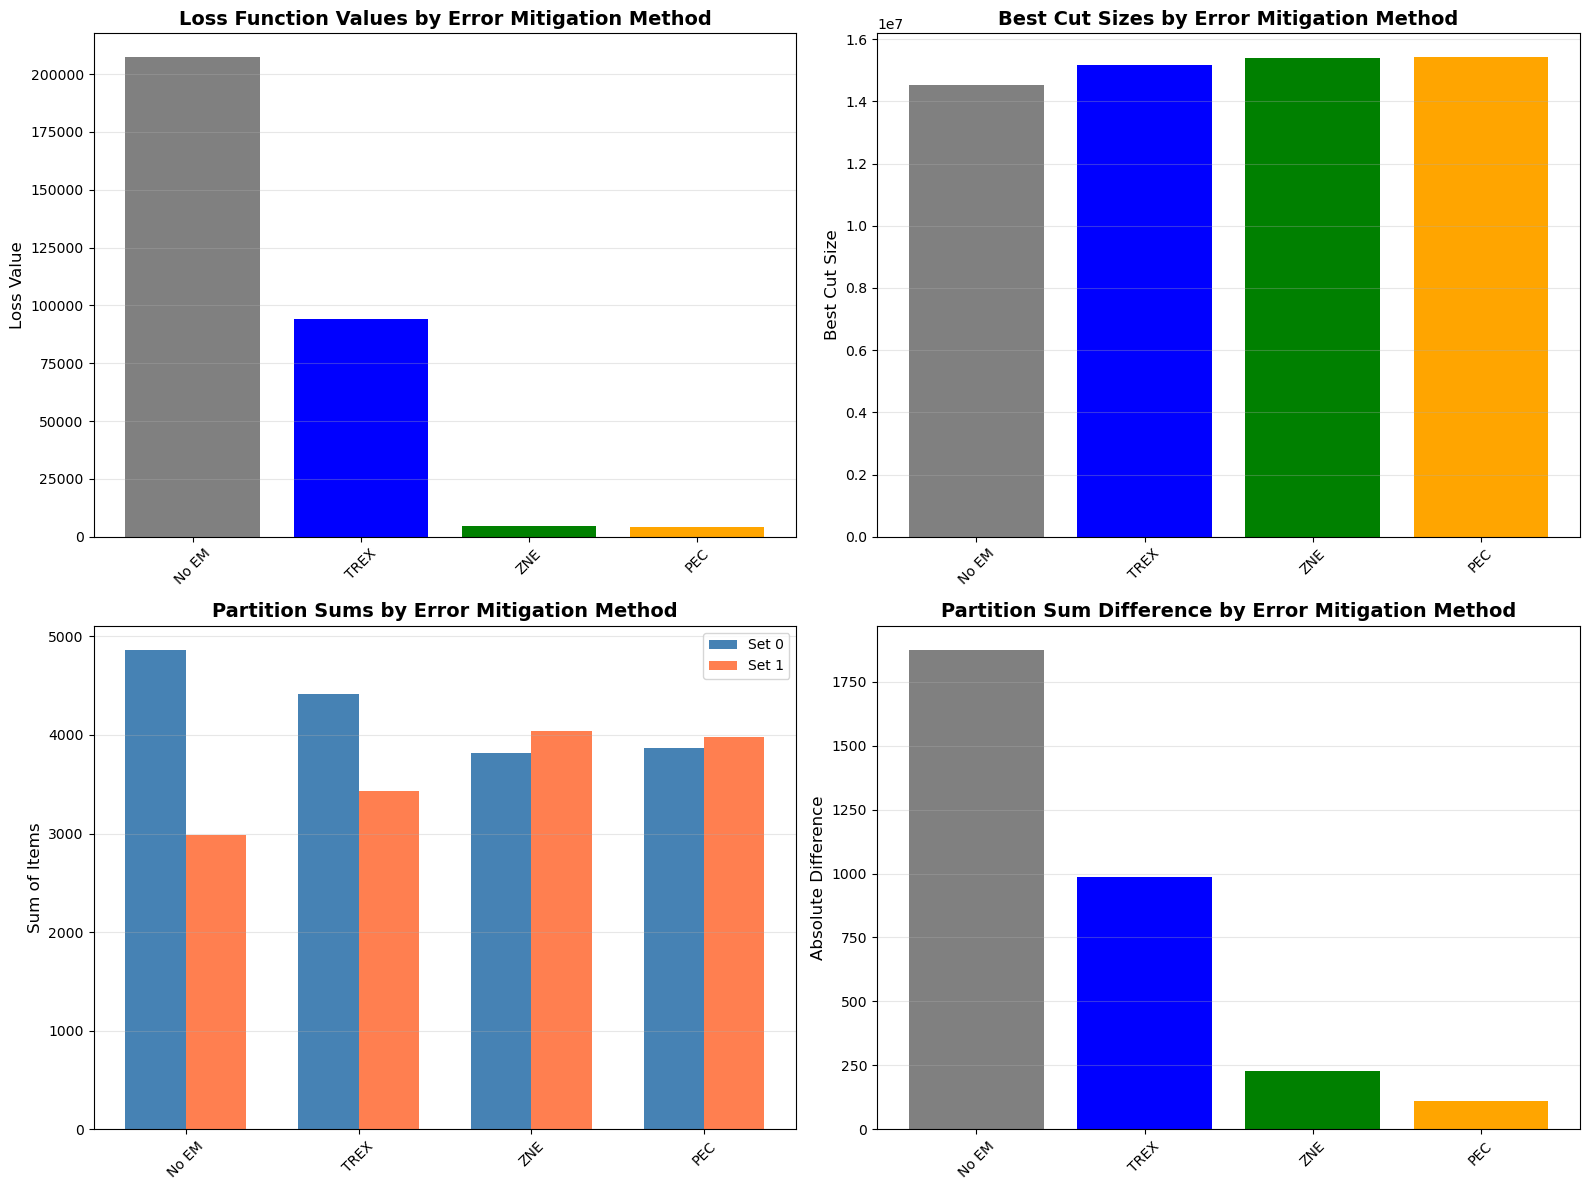
</div>

In [ ]:
estimator_options_list = [
    est_options_no_em,
    est_options_trex,
    est_options_zne,
    est_options_pec,
]
jobs_est_list = [job_no_em, job_trex, job_zne, job_pec]

The grader cell below will verify that your jobs correctly apply the previously defined `EstimatorOptions` and assess the quality of your results to confirm you obtained a valid solution to the partition problem.

In [ ]:
## Verify your answer ##
grade_lab4b_ex4(estimator_options_list, results, jobs_est_list)

## Conclusion

Congratulations on completing Lab 4b! 🎉

In this lab, you explored the partition problem and learned how to formulate it as a QUBO problem suitable for current quantum computers using the QAOA algorithm. You have also experienced how advanced error mitigation and suppression techniques can significantly improve QAOA performance on real quantum hardware. Additionally, you implemented smart encoding strategies that reduce the qubit requirements, enabling you to solve problem instances on current QPUs that would be intractable with naive encoding approaches.

This Lab serves as a demonstration that a combination of the adequate quantum algorithm combined with tailored error-handling strategies and efficient encodings could brings us one step closer to solving real-world problems and demonstrating quantum advantage for classically verifiable problems.

Now, if you enjoyed this problem and are ready to take it to the next level, the bonus section will show you how to tackle a problem 10 times larger: finding the partition of a list containing 1600 numbers!
